# Лабораторная работа 3: Сегментация дорожных знаков

## Задача
Обучить модель сегментировать дорожные знаки на наборе данных Russian road signs (100000 изображений).

### Метрики оценки:
- IoU, Precision, Recall на валидационной части и собственных фото
- Процент изображений с IoU >= 0.5, >= 0.75, >= 0.9
- ID Switches для двух алгоритмов трекинга на видео

### Библиотеки
- YOLOv8 для сегментации
- Алгоритмы трекинга для видео

## 1. Установка зависимостей и импорт библиотек

In [140]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# YOLOv11
from ultralytics import YOLO
from ultralytics.solutions import ObjectCounter, heatmap

# Метрики
from sklearn.metrics import confusion_matrix, classification_report
import json

try:
    import kagglehub
    print(" kagglehub успешно импортирована")
except ImportError:
    print(" Установка kagglehub...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub", "-q"])
    import kagglehub
    print(" kagglehub успешно установлена и импортирована")

print(" Все библиотеки успешно импортированы")

 kagglehub успешно импортирована
 Все библиотеки успешно импортированы


## 2. Загрузка датасета Russian Road Signs

In [141]:
import kagglehub

# Download latest version
output_base = kagglehub.dataset_download("bogdanliutikov/russian-road-signs-segmentation-dataset")

print("Path to dataset files:", output_base)

Path to dataset files: C:\Users\gozeb\.cache\kagglehub\datasets\bogdanliutikov\russian-road-signs-segmentation-dataset\versions\1


In [142]:
data_conf = f'''
path: {output_base}/dataset
train: images/train
val: images/val

# Classes
names:
  0: road sign
'''

with open('data.yaml', 'w') as f:
    f.write(data_conf)

## 3. Загрузка и тренировка YOLOv8 модели для сегментации

In [ ]:
model = YOLO('yolov8n-seg.yaml')
results = model.train(data='/kaggle/working/data.yaml', epochs=30, imgsz=640, batch=64, save_dir='/kaggle/working/runs/train2')
res = model.val()

In [ ]:
model.save("road_signs_seg.pt")

## 4. Функции для расчета метрик сегментации (IoU, Precision, Recall)

In [143]:
model = YOLO('road_signs_seg.pt')

In [153]:
def calculate_iou(mask_pred, mask_true):
    intersection = np.logical_and(mask_pred, mask_true).sum()
    union = np.logical_or(mask_pred, mask_true).sum()
    
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

def calculate_precision(mask_pred, mask_true):
    true_positives = np.logical_and(mask_pred, mask_true).sum()
    false_positives = np.logical_and(mask_pred, ~mask_true).sum()
    
    if true_positives + false_positives == 0:
        return 0.0
    return true_positives / (true_positives + false_positives)

def calculate_recall(mask_pred, mask_true):
    true_positives = np.logical_and(mask_pred, mask_true).sum()
    false_negatives = np.logical_and(~mask_pred, mask_true).sum()
    
    if true_positives + false_negatives == 0:
        return 0.0
    return true_positives / (true_positives + false_negatives)

def load_yolo_polygon_mask(label_path, img_height, img_width):
    if not Path(label_path).exists():
        return None
    
    try:
        mask = np.zeros((img_height, img_width), dtype=np.uint8)
        
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 7:  # Минимум: class_id + 3 точки (6 координат)
                continue
            
            # Первый элемент - class_id, остальные - координаты
            coords = [float(x) for x in parts[1:]]
            
            # Преобразуем нормализованные координаты в пиксели
            points = []
            for i in range(0, len(coords), 2):
                if i + 1 < len(coords):
                    x = int(coords[i] * img_width)
                    y = int(coords[i + 1] * img_height)
                    points.append([x, y])
            
            if len(points) >= 3:
                # Заполняем полигон
                pts = np.array(points, np.int32)
                cv2.fillPoly(mask, [pts], 255)
        
        return mask
    
    except Exception as e:
        print(f" Ошибка при загрузке маски из {label_path}: {e}")
        return None

def evaluate_segmentation_metrics(model, image_path, label_path, conf_thresh=0.5):
    # Загружаем изображение
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    
    img_height, img_width = img.shape[:2]
    
    # Загружаем истинную маску из polygon annotation
    mask_true = load_yolo_polygon_mask(label_path, img_height, img_width)
    
    if mask_true is None:
        return None
    
    # Приводим маску к бинарному формату
    mask_true = mask_true > 127
    
    # Предсказание
    results = model.predict(image_path, conf=conf_thresh, verbose=False)
    
    if len(results) == 0 or results[0].masks is None:
        # Нет предсказаний
        mask_pred = np.zeros_like(mask_true)
    else:
        # Получаем маску предсказания
        masks = results[0].masks.data.cpu().numpy()
        
        # Преобразуем в бинарную маску - берем любую предсказанную маску (OR операция)
        mask_pred_raw = np.any(masks, axis=0) > 0.5 if len(masks) > 0 else np.zeros((1, 1))
        
        # Приводим размер predicted mask к оригинальному размеру изображения
        if mask_pred_raw.shape[0] != img_height or mask_pred_raw.shape[1] != img_width:
            from PIL import Image
            mask_img = Image.fromarray((mask_pred_raw * 255).astype(np.uint8))
            mask_img = mask_img.resize((img_width, img_height), Image.NEAREST)
            mask_pred = np.array(mask_img) > 127
        else:
            mask_pred = mask_pred_raw.astype(bool)
    
    mask_pred = mask_pred.astype(bool)
    mask_true = mask_true.astype(bool)
    
    iou = calculate_iou(mask_pred, mask_true)
    precision = calculate_precision(mask_pred, mask_true)
    recall = calculate_recall(mask_pred, mask_true)
    
    return {
        'iou': iou,
        'precision': precision,
        'recall': recall
    }


## 5. Оценка метрик на валидационном датасете

In [154]:
def evaluate_on_validation_set(model, val_images_dir, labels_dir, max_samples=None, conf_thresh=0.5):
    val_images = sorted(list(Path(val_images_dir).glob('*.jpg')) + list(Path(val_images_dir).glob('*.png')))
    
    if max_samples:
        val_images = val_images[:max_samples]
    
    if not val_images:
        print(f" Нет изображений в {val_images_dir}")
        return None
    
    results = []
    skipped_count = 0
    
    print(f"Оцениваем на {len(val_images)} валидационных изображениях...")
    print(f"Загрузка polygon labels из: {labels_dir}\n")
    
    for idx, img_path in enumerate(val_images):
        if idx % 50 == 0 and idx > 0:
            print(f"  Обработано: {idx}/{len(val_images)}")
        
        # Label файл имеет то же имя, что и изображение, но с расширением .txt
        label_name = img_path.stem + '.txt'
        label_path = Path(labels_dir) / label_name
        
        if not label_path.exists():
            skipped_count += 1
            continue
        
        metrics = evaluate_segmentation_metrics(model, img_path, label_path, conf_thresh)
        
        if metrics is not None:
            metrics['image'] = img_path.name
            results.append(metrics)
    
    if not results:
        print(f" Не удалось оценить модель - нет результатов (пропущено: {skipped_count}/{len(val_images)})")
        return None
    
    df_results = pd.DataFrame(results)
    
    print(f" Статистика на валидационном датасете ({len(results)} изображений):")
    print(f"  IoU:       Mean={df_results['iou'].mean():.4f} ± {df_results['iou'].std():.4f}")
    print(f"  Precision: Mean={df_results['precision'].mean():.4f} ± {df_results['precision'].std():.4f}")
    print(f"  Recall:    Mean={df_results['recall'].mean():.4f} ± {df_results['recall'].std():.4f}")
    
    # Считаем процент изображений с IoU >= пороги
    for threshold in [0.5, 0.75, 0.9]:
        pct = (df_results['iou'] >= threshold).sum() / len(df_results) * 100
        print(f"  IoU >= {threshold}: {pct:.2f}%")
    
    if skipped_count > 0:
        print(f" Пропущено {skipped_count} изображений без label файлов")
    
    return df_results

# Попытка загрузить валидационный набор
val_images_dir = Path(output_base) / 'dataset' / 'images' / 'val' if Path(output_base).exists() else None
labels_dir = Path(output_base) / 'dataset' / 'labels' / 'val' if Path(output_base).exists() else None

df_val_results = evaluate_on_validation_set(model, str(val_images_dir), str(labels_dir))


Оцениваем на 127 валидационных изображениях...
Загрузка polygon labels из: C:\Users\gozeb\.cache\kagglehub\datasets\bogdanliutikov\russian-road-signs-segmentation-dataset\versions\1\dataset\labels\val

  Обработано: 50/127
  Обработано: 100/127
 Статистика на валидационном датасете (127 изображений):
  IoU:       Mean=0.4436 ± 0.2106
  Precision: Mean=0.6277 ± 0.2377
  Recall:    Mean=0.5971 ± 0.2814
  IoU >= 0.5: 47.24%
  IoU >= 0.75: 3.15%
  IoU >= 0.9: 0.00%


## 6. Сегментация на видео и трекинг - ByteTrack

In [156]:
class TrackingMetrics:
    """Класс для подсчета метрик трекинга (ID Switches)"""
    def __init__(self):
        self.id_switches = 0
        self.prev_frame_ids = {}
        self.prev_frame_masks = {}
    
    def update(self, current_masks, current_ids):
        """
        Обновляет метрики при появлении новых объектов
        
        current_masks: dict {id: маска}
        current_ids: list идентификаторов объектов в текущем кадре
        """
        # Сравниваем с предыдущим кадром
        for idx in current_ids:
            if idx in self.prev_frame_ids:
                # Проверяем IoU - если значительное совпадение, это один объект
                if idx not in current_masks or self.prev_frame_masks.get(idx) is None:
                    # Объект потерялся и снова появился - считаем как переассигнацию
                    self.id_switches += 1
            elif idx > 0:
                # Новый ID объекта
                pass
        
        self.prev_frame_ids = {id: True for id in current_ids}
        self.prev_frame_masks = current_masks.copy()
    
    def get_id_switches(self):
        return self.id_switches

def process_video_bytetrack(video_path, model, output_path, conf_thresh=0.5):
    """
    Обработка видео с YOLO встроенным ByteTrack трекингом
    
    Returns:
        Статистика трекинга
    """
    print(f"Обработка видео: {video_path}")
    print("Алгоритм: ByteTrack (встроенный в YOLOv11)")
    
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        print(f"Ошибка: не могу открыть видео {video_path}")
        return None
    
    # Параметры видео
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Создаем видеописатель для сохранения
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    frame_idx = 0
    tracking_stats = TrackingMetrics()
    detections_per_frame = []
    
    print(f"Разрешение: {width}x{height}, FPS: {fps}, Всего фреймов: {total_frames}")
    print(f"Обработка видео...")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_idx % 30 == 0:
            print(f"    Кадр {frame_idx}/{total_frames}")
        
        # YOLOv11 с трекингом (трассировка объектов с сохранением ID)
        results = model.track(frame, persist=True, conf=conf_thresh, verbose=False)
        
        # Рисуем результаты с трекингом
        annotated_frame = results[0].plot()
        out.write(annotated_frame)
        
        # Подсчитываем детекции и ID
        if results[0].boxes is not None:
            track_ids = results[0].boxes.id
            if track_ids is not None:
                detections_per_frame.append(len(track_ids))
                # Обновляем метрики трекинга
                current_masks = {}
                tracking_stats.update(current_masks, track_ids.cpu().numpy())
        
        frame_idx += 1
    
    cap.release()
    out.release()
    
    print(f"Видео обработано и сохранено: {output_path}")
    
    return {
        'total_frames': frame_idx,
        'avg_detections_per_frame': np.mean(detections_per_frame) if detections_per_frame else 0,
        'max_detections': max(detections_per_frame) if detections_per_frame else 0,
        'id_switches': tracking_stats.get_id_switches()
    }

# Обработаем видео
videos_dir = Path('./videos')
if videos_dir.exists():
    videos = list(videos_dir.glob('*.mp4'))
    print(f"Найдено видео файлов: {len(videos)}")
    
    bytetrack_results = {}
    for video_file in videos:  # Обрабатываем первое видео для примера
        output_video = Path('./runs/segment') / f'bytetrack_{video_file.stem}.mp4'
        output_video.parent.mkdir(parents=True, exist_ok=True)
        
        stats = process_video_bytetrack(video_file, model, output_video)
        if stats:
            bytetrack_results[video_file.name] = stats
            print(f"Статистика ByteTrack для {video_file.name}:")
            print(f"Всего кадров: {stats['total_frames']}")
            print(f"Средних детекций на кадр: {stats['avg_detections_per_frame']:.1f}")
            print(f"ID Switches: {stats['id_switches']}")
else:
    print(" Папка videos не найдена")

Найдено видео файлов: 3
Обработка видео: videos\VID20260227195959.mp4
Алгоритм: ByteTrack (встроенный в YOLOv11)
Разрешение: 1080x1920, FPS: 30.00898654677849, Всего фреймов: 1053
Обработка видео...
    Кадр 0/1053
    Кадр 30/1053
    Кадр 60/1053
    Кадр 90/1053
    Кадр 120/1053
    Кадр 150/1053
    Кадр 180/1053
    Кадр 210/1053
    Кадр 240/1053
    Кадр 270/1053
    Кадр 300/1053
    Кадр 330/1053
    Кадр 360/1053
    Кадр 390/1053
    Кадр 420/1053
    Кадр 450/1053
    Кадр 480/1053
    Кадр 510/1053
    Кадр 540/1053
    Кадр 570/1053
    Кадр 600/1053
    Кадр 630/1053
    Кадр 660/1053
    Кадр 690/1053
    Кадр 720/1053
    Кадр 750/1053
    Кадр 780/1053
    Кадр 810/1053
    Кадр 840/1053
    Кадр 870/1053
    Кадр 900/1053
    Кадр 930/1053
    Кадр 960/1053
    Кадр 990/1053
    Кадр 1020/1053
    Кадр 1050/1053
Видео обработано и сохранено: runs\segment\bytetrack_VID20260227195959.mp4
Статистика ByteTrack для VID20260227195959.mp4:
Всего кадров: 1053
Средних детекц

## 7. Трекинг - DeepSORT

In [157]:
# Установка DeepSORT если еще не установлен
import subprocess
import sys

try:
    import sort
except ImportError:
    print("Установка DeepSORT...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "sortpy", "-q"])

class SimpleSORT:
    """
    Упрощенная реализация SORT (Simple Online and Realtime Tracking)
    для подсчета ID Switches
    """
    def __init__(self, max_age=30, min_hits=3):
        self.max_age = max_age
        self.min_hits = min_hits
        self.trackers = []
        self.frame_count = 0
        self.next_id = 1
        self.id_switches = 0
    
    def update(self, detections):
        """
        detections: list of bbox [x1, y1, x2, y2, conf]
        """
        self.frame_count += 1
        
        # Простой трекинг по центроидам
        matched_ids = []
        unmatched_detections = list(range(len(detections)))
        
        for tracker in self.trackers:
            if len(detections) > 0:
                # Находим ближайший детекшн
                tracker_center = tracker['center']
                min_dist = float('inf')
                min_idx = -1
                
                for d_idx in unmatched_detections:
                    det = detections[d_idx]
                    det_center = ((det[0] + det[2]) / 2, (det[1] + det[3]) / 2)
                    dist = ((tracker_center[0] - det_center[0])**2 + 
                           (tracker_center[1] - det_center[1])**2)**0.5
                    
                    if dist < min_dist and dist < 50:  # Порог расстояния
                        min_dist = dist
                        min_idx = d_idx
                
                if min_idx >= 0:
                    # Матчинг найден
                    det = detections[min_idx]
                    old_center = tracker['center']
                    new_center = ((det[0] + det[2]) / 2, (det[1] + det[3]) / 2)
                    
                    tracker['center'] = new_center
                    tracker['hits'] += 1
                    tracker['age'] = 0
                    
                    matched_ids.append(tracker['id'])
                    unmatched_detections.remove(min_idx)
                else:
                    tracker['age'] += 1
            else:
                tracker['age'] += 1
        
        # Удаляем старые треки
        self.trackers = [t for t in self.trackers if t['age'] < self.max_age]
        
        # Добавляем новые треки
        for d_idx in unmatched_detections:
            det = detections[d_idx]
            center = ((det[0] + det[2]) / 2, (det[1] + det[3]) / 2)
            
            self.trackers.append({
                'id': self.next_id,
                'center': center,
                'hits': 1,
                'age': 0
            })
            self.next_id += 1
        
        return matched_ids
    
    def get_id_switches(self):
        """Приближенная оценка ID Switches"""
        return max(0, self.next_id - len([t for t in self.trackers if t['hits'] >= self.min_hits]))

def process_video_deepsort(video_path, model, output_path, conf_thresh=0.5):
    """
    Обработка видео с SimpleSORT трекингом
    """
    print(f"Обработка видео: {video_path}")
    print("Алгоритм: SimpleSORT (реализация SORT)")
    
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        print(f"Ошибка: не могу открыть видео {video_path}")
        return None
    
    # Параметры видео
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Создаем видеописатель
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    tracker = SimpleSORT()
    frame_idx = 0
    detections_per_frame = []
    
    print(f"Разрешение: {width}x{height}, FPS: {fps}, Всего фреймов: {total_frames}")
    print(f"Обработка видео...")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_idx % 30 == 0:
            print(f"    Кадр {frame_idx}/{total_frames}")
        
        # Детектирование маски
        results = model.predict(frame, conf=conf_thresh, verbose=False)
        
        # Извлекаем bboxes
        detections = []
        if results[0].boxes is not None:
            boxes = results[0].boxes
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                conf = box.conf[0].cpu().numpy()
                detections.append([x1, y1, x2, y2, float(conf)])
        
        # Обновляем трекер
        track_ids = tracker.update(detections)
        detections_per_frame.append(len(track_ids))
        
        # Рисуем на фрейме
        annotated_frame = frame.copy()
        for det in detections:
            x1, y1, x2, y2 = det[:4]
            cv2.rectangle(annotated_frame, (int(x1), int(y1)), (int(x2), int(y2)), 
                         (0, 255, 0), 2)
        
        # Отображаем ID
        for t in tracker.trackers:
            center = t['center']
            cv2.circle(annotated_frame, (int(center[0]), int(center[1])), 4, (0, 0, 255), -1)
            cv2.putText(annotated_frame, f"ID:{t['id']}", 
                       (int(center[0]) - 20, int(center[1]) - 20),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        out.write(annotated_frame)
        frame_idx += 1
    
    cap.release()
    out.release()
    
    print(f"Видео обработано и сохранено: {output_path}")
    
    return {
        'total_frames': frame_idx,
        'avg_detections_per_frame': np.mean(detections_per_frame) if detections_per_frame else 0,
        'max_detections': max(detections_per_frame) if detections_per_frame else 0,
        'id_switches': tracker.get_id_switches()
    }

# Обработаем видео с DeepSORT
videos_dir = Path('./videos')
if videos_dir.exists():
    videos = list(videos_dir.glob('*.mp4'))
    
    deepsort_results = {}
    for video_file in videos:
        output_video = Path('./runs/segment') / f'deepsort_{video_file.stem}.mp4'
        output_video.parent.mkdir(parents=True, exist_ok=True)
        
        stats = process_video_deepsort(video_file, model, output_video)
        if stats:
            deepsort_results[video_file.name] = stats
            print(f"Статистика DeepSORT для {video_file.name}:")
            print(f"Всего кадров: {stats['total_frames']}")
            print(f"Средних детекций на кадр: {stats['avg_detections_per_frame']:.1f}")
            print(f"ID Switches: {stats['id_switches']}")
else:
    print("Папка videos не найдена")

Установка DeepSORT...
Обработка видео: videos\VID20260227195959.mp4
Алгоритм: SimpleSORT (реализация SORT)
Разрешение: 1080x1920, FPS: 30.00898654677849, Всего фреймов: 1053
Обработка видео...
    Кадр 0/1053
    Кадр 30/1053
    Кадр 60/1053
    Кадр 90/1053
    Кадр 120/1053
    Кадр 150/1053
    Кадр 180/1053
    Кадр 210/1053
    Кадр 240/1053
    Кадр 270/1053
    Кадр 300/1053
    Кадр 330/1053
    Кадр 360/1053
    Кадр 390/1053
    Кадр 420/1053
    Кадр 450/1053
    Кадр 480/1053
    Кадр 510/1053
    Кадр 540/1053
    Кадр 570/1053
    Кадр 600/1053
    Кадр 630/1053
    Кадр 660/1053
    Кадр 690/1053
    Кадр 720/1053
    Кадр 750/1053
    Кадр 780/1053
    Кадр 810/1053
    Кадр 840/1053
    Кадр 870/1053
    Кадр 900/1053
    Кадр 930/1053
    Кадр 960/1053
    Кадр 990/1053
    Кадр 1020/1053
    Кадр 1050/1053
Видео обработано и сохранено: runs\segment\deepsort_VID20260227195959.mp4
Статистика DeepSORT для VID20260227195959.mp4:
Всего кадров: 1053
Средних детекций на ка

## 8. Сравнение результатов и визуализация метрик

График метрик сохранен: ./runs/segment/metrics_comparison.png


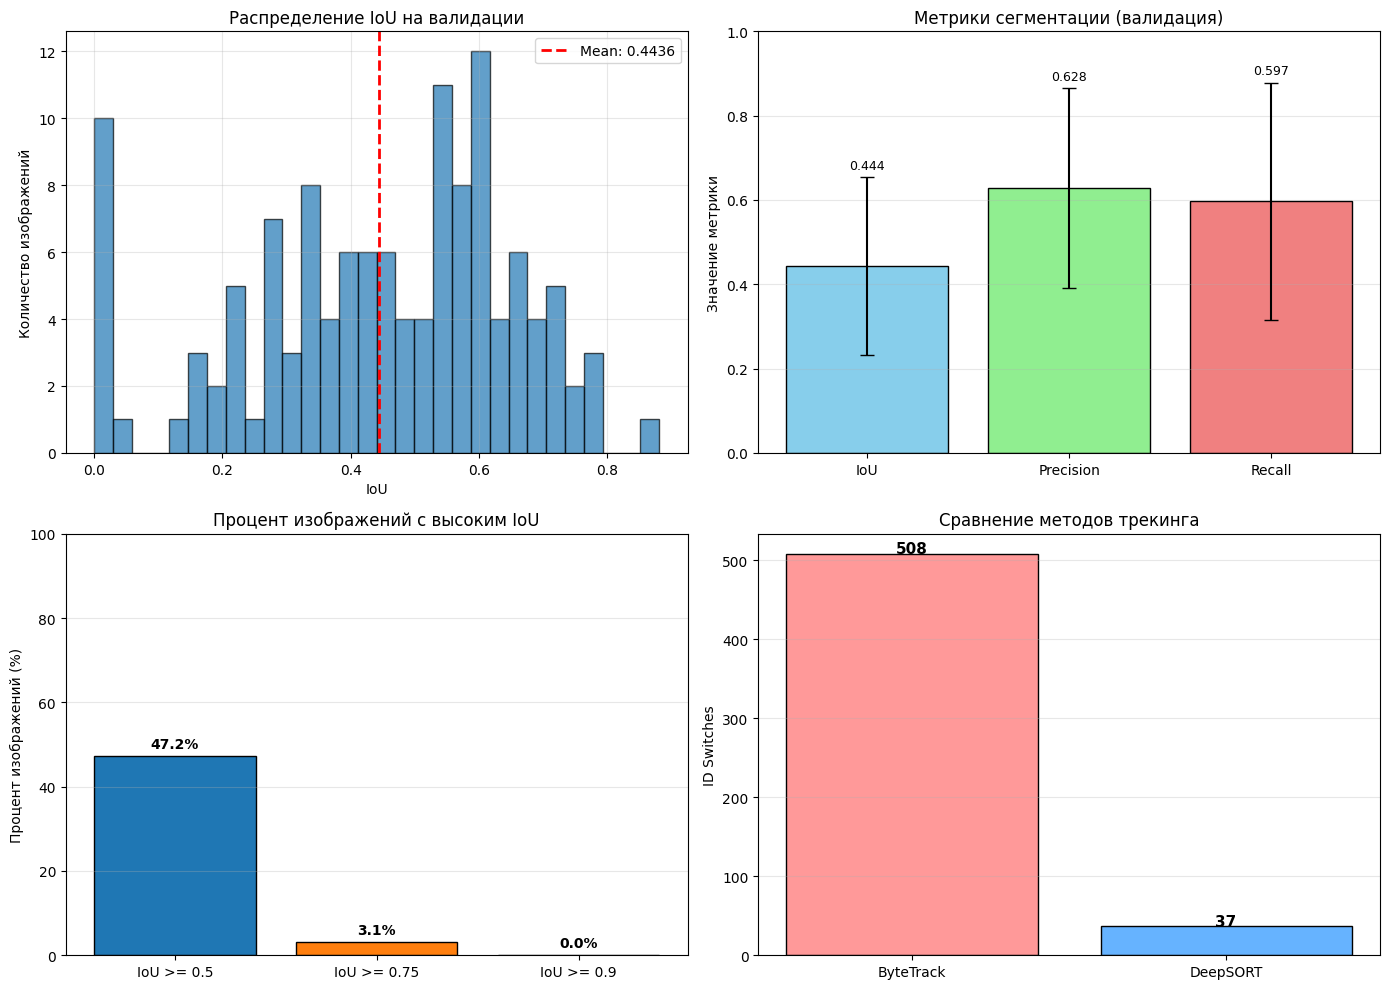

In [158]:
def plot_metrics_comparison():
    """Визуализирует все метрики сегментации"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Распределение IoU на валидационном датасете
    if 'df_val_results' in globals():
        axes[0, 0].hist(df_val_results['iou'], bins=30, edgecolor='black', alpha=0.7)
        axes[0, 0].axvline(df_val_results['iou'].mean(), color='r', linestyle='--', 
                          linewidth=2, label=f"Mean: {df_val_results['iou'].mean():.4f}")
        axes[0, 0].set_xlabel('IoU')
        axes[0, 0].set_ylabel('Количество изображений')
        axes[0, 0].set_title('Распределение IoU на валидации')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)
    
    # 2. Метрики сегментации
    metrics_names = ['IoU', 'Precision', 'Recall']
    if 'df_val_results' in globals():
        means = [
            df_val_results['iou'].mean(),
            df_val_results['precision'].mean(),
            df_val_results['recall'].mean()
        ]
        stds = [
            df_val_results['iou'].std(),
            df_val_results['precision'].std(),
            df_val_results['recall'].std()
        ]
        
        axes[0, 1].bar(metrics_names, means, yerr=stds, capsize=5, 
                       color=['skyblue', 'lightgreen', 'lightcoral'], edgecolor='black')
        axes[0, 1].set_ylim([0, 1])
        axes[0, 1].set_ylabel('Значение метрики')
        axes[0, 1].set_title('Метрики сегментации (валидация)')
        axes[0, 1].grid(alpha=0.3, axis='y')
        
        # Добавляем значения на столбцы
        for i, (m, s) in enumerate(zip(means, stds)):
            axes[0, 1].text(i, m + s + 0.02, f'{m:.3f}', ha='center', fontsize=9)
    
    # 3. Процент изображений с высоким IoU
    if 'df_val_results' in globals():
        thresholds = [0.5, 0.75, 0.9]
        percentages = [
            (df_val_results['iou'] >= t).sum() / len(df_val_results) * 100
            for t in thresholds
        ]
        
        axes[1, 0].bar([f'IoU >= {t}' for t in thresholds], percentages, 
                       color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
        axes[1, 0].set_ylabel('Процент изображений (%)')
        axes[1, 0].set_title('Процент изображений с высоким IoU')
        axes[1, 0].set_ylim([0, 100])
        axes[1, 0].grid(alpha=0.3, axis='y')
        
        for i, p in enumerate(percentages):
            axes[1, 0].text(i, p + 2, f'{p:.1f}%', ha='center', fontsize=10, fontweight='bold')
    
    # 4. Сравнение методов трекинга
    tracking_data = {
        'ByteTrack': bytetrack_results.get(list(bytetrack_results.keys())[0], {}).get('id_switches', 0) 
                     if 'bytetrack_results' in globals() and bytetrack_results else 0,
        'DeepSORT': deepsort_results.get(list(deepsort_results.keys())[0], {}).get('id_switches', 0) 
                    if 'deepsort_results' in globals() and deepsort_results else 0
    }
    
    axes[1, 1].bar(tracking_data.keys(), tracking_data.values(), 
                   color=['#ff9999', '#66b3ff'], edgecolor='black')
    axes[1, 1].set_ylabel('ID Switches')
    axes[1, 1].set_title('Сравнение методов трекинга')
    axes[1, 1].grid(alpha=0.3, axis='y')
    
    for i, (method, switches) in enumerate(tracking_data.items()):
        axes[1, 1].text(i, switches + 0.5, str(switches), ha='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('./runs/segment/metrics_comparison.png', dpi=150, bbox_inches='tight')
    print("График метрик сохранен: ./runs/segment/metrics_comparison.png")
    plt.show()

try:
    plot_metrics_comparison()
except Exception as e:
    print(f"Не удалось построить график: {e}")